In [2]:
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

np.bool8 = np.bool_

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
class DuelingQNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions):
        super(DuelingQNetwork, self).__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        x = self.shared(x)
        value = self.value_stream(x)
        advantage = self.advantage_stream(x)
        q_vals = value + (advantage - advantage.mean(dim=1, keepdim=True))
        return q_vals

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, s, a, r, s_, done):
        self.buffer.append((s, a, r, s_, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_, d = zip(*batch)
        return (
            torch.FloatTensor(s).to(device),
            torch.LongTensor(a).unsqueeze(1).to(device),
            torch.FloatTensor(r).unsqueeze(1).to(device),
            torch.FloatTensor(s_).to(device),
            torch.FloatTensor(d).unsqueeze(1).to(device)
        )
    
    def __len__(self):
        return len(self.buffer)

## Dueling DQN Architecture

### Main Ideas:

1. **Separation of Value and Advantage**:
   The key idea in the **dueling architecture** is to separate the estimation of:
   - The **value of being in a particular state** (state-value function $ V(s) $).
   - The **advantage of each action** in that state (advantage function \( A(s, a) \)).
   
   The network is split into two streams after a shared layer, where:
   - One stream estimates the state-value \( V(s) \).
   - The other stream estimates the advantage \( A(s, a) \).

2. **Combining Value and Advantage**:
   After the two streams (value and advantage) are computed, they are combined to form the final Q-value. The Q-value is computed using the following formula:
   $$
   Q(s, a) = V(s) + \left( A(s, a) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a') \right)
   $$
   The term $ \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a') $ ensures that the advantage stream is normalized, avoiding redundancy in the Q-value calculation.

3. **Why Dueling Architecture?**
   - In many states, it is unnecessary to know the value of each action explicitly. For example, in some states, any action might have little effect on the outcome.
   - The **dueling network** allows the agent to compute the value of a state without requiring precise Q-value estimates for each action in every state.
   - This results in **more stable learning** and better generalization.

4. **Better Performance in Sparse Reward Environments**:
   - The separation of state-value and advantage helps the agent learn more efficiently, particularly in environments where many actions have similar effects.
   - It is especially useful in **sparse reward environments**, where the difference between actions may not be immediately clear.

### Structure of the Dueling DQN:

- **Shared Layers**: The initial layers are shared, allowing the network to extract features common to both the value and advantage estimations.
- **Value Stream**: A fully connected layer that estimates \( V(s) \), the value of the current state.
- **Advantage Stream**: A fully connected layer that estimates \( A(s, a) \), the advantage of each action given the current state.
- **Output Layer**: Combines the value and advantage streams to produce the Q-values for each action.


In [6]:
class DuelingDQNAgent:
    def __init__(self, obs_dim, n_actions, gamma=0.99, lr=0.001, buffer_size=20000):
        self.obs_dim = obs_dim
        self.n_actions = n_actions
        self.gamma = gamma

        self.model = DuelingQNetwork(obs_dim, n_actions).to(device)
        self.target_model = DuelingQNetwork(obs_dim, n_actions).to(device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()

        self.buffer = ReplayBuffer(buffer_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def act(self, state, epsilon=0.05):
        if random.random() < epsilon:
            return random.randint(0, self.n_actions - 1)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return q_values.argmax(dim=1).item()

    def remember(self, s, a, r, s_, done):
        self.buffer.push(s, a, r, s_, done)

    def train(self, batch_size=32):
        if len(self.buffer) < batch_size:
            return

        S, A, R, S_, D = self.buffer.sample(batch_size)

        # Q(s, a)
        current_q = self.model(S).gather(1, A)

        # Q(s', a') from target
        with torch.no_grad():
            next_q = self.target_model(S_).max(1)[0].unsqueeze(1)
            target_q = R + self.gamma * next_q * (1 - D)

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())



C:\Users\admin\AppData\Local\Temp\ipykernel_20128\756047006.py:12: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  torch.FloatTensor(s).to(device),


Ep   0 | Score: -595.25 | Avg(50): -595.25 | Epsilon: 0.05
Ep   1 | Score: -103.05 | Avg(50): -349.15 | Epsilon: 0.05
Ep   2 | Score: -106.16 | Avg(50): -268.15 | Epsilon: 0.05
Ep   3 | Score: -151.79 | Avg(50): -239.06 | Epsilon: 0.05
Ep   4 | Score: -314.78 | Avg(50): -254.21 | Epsilon: 0.05
Ep   5 | Score: -360.23 | Avg(50): -271.88 | Epsilon: 0.05
Ep   6 | Score: -206.47 | Avg(50): -262.53 | Epsilon: 0.05
Ep   7 | Score: -130.29 | Avg(50): -246.00 | Epsilon: 0.05
Ep   8 | Score: -143.56 | Avg(50): -234.62 | Epsilon: 0.05
Ep   9 | Score: -290.63 | Avg(50): -240.22 | Epsilon: 0.05
Ep  10 | Score: -263.08 | Avg(50): -242.30 | Epsilon: 0.05
Ep  11 | Score: -215.71 | Avg(50): -240.08 | Epsilon: 0.05
Ep  12 | Score: -171.57 | Avg(50): -234.81 | Epsilon: 0.05
Ep  13 | Score:  -84.90 | Avg(50): -224.10 | Epsilon: 0.05
Ep  14 | Score:  -42.45 | Avg(50): -211.99 | Epsilon: 0.05
Ep  15 | Score: -312.87 | Avg(50): -218.30 | Epsilon: 0.05
Ep  16 | Score: -239.61 | Avg(50): -219.55 | Epsilon: 0.

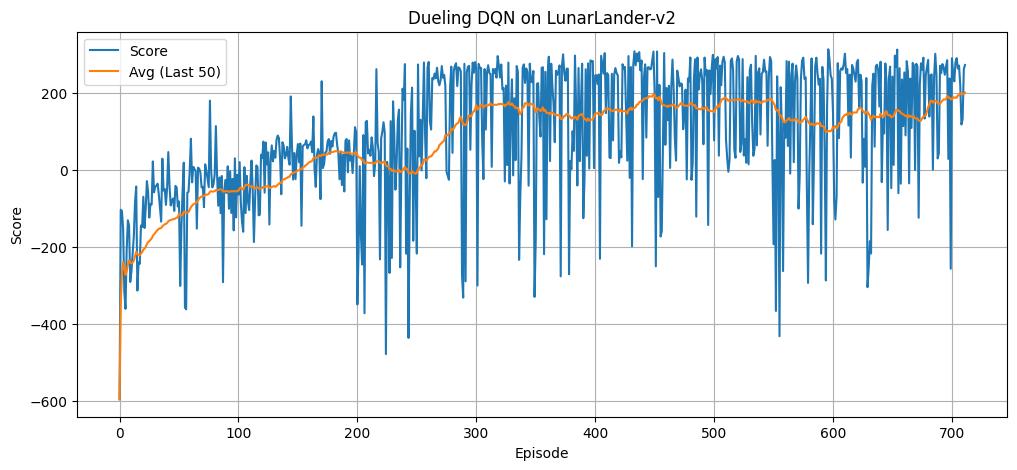

In [7]:
env = gym.make("LunarLander-v2")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
agent = DuelingDQNAgent(obs_dim, n_actions)

# Training loop
episodes = 2000
max_t = 500
epsilon = 0.05
update_freq = 400
time_step = 0

scores = []
avgs = []

for episode in range(episodes):
    state, _ = env.reset()
    score = 0

    for t in range(max_t):
        time_step += 1
        action = agent.act(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        agent.train(batch_size=32)

        if time_step % update_freq == 0:
            agent.update_target()

        state = next_state
        score += reward

        if done:
            break

    scores.append(score)
    avg_score = np.mean(scores[-50:])
    avgs.append(avg_score)

    print(f"Ep {episode:3d} | Score: {score:7.2f} | Avg(50): {avg_score:7.2f} | Epsilon: {epsilon:.2f}")
    
    if avg_score >= 200:
        print("Environment solved!")
        break

# Plot results
plt.figure(figsize=(12,5))
plt.plot(scores, label="Score")
plt.plot(avgs, label="Avg (Last 50)")
plt.xlabel("Episode")
plt.ylabel("Score")
plt.title("Dueling DQN on LunarLander-v2")
plt.legend()
plt.grid()
plt.show()